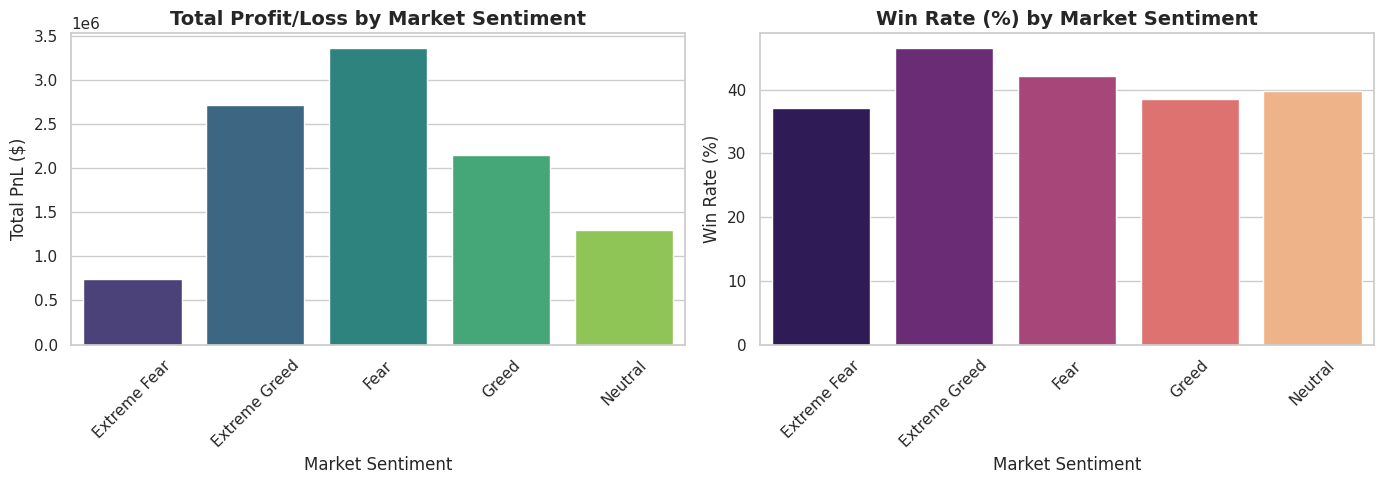


FINAL OBSERVATION (CONCLUSION)
Based on the analysis, the trader performs exceptionally well during 'Fear' market conditions.
They generated a maximum total profit of $3357155.44 with a solid win rate of 42.08%.
Conversely, the trader's performance drops during 'Extreme Fear' conditions, where the total PnL is $739110.25.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# PART A: Data Preparation and Merging
# ==========================================
# 1. Load Data
trades_df = pd.read_csv('historical_data.csv')
sentiment_df = pd.read_csv('fear_greed_index.csv')

# 2. Clean Dates and Merge
trades_df['Timestamp IST'] = pd.to_datetime(trades_df['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades_df['Date'] = trades_df['Timestamp IST'].dt.strftime('%Y-%m-%d')
sentiment_df.rename(columns={'date': 'Date'}, inplace=True)
merged_df = pd.merge(trades_df, sentiment_df, on='Date', how='inner')

# ==========================================
# PART B: Performance Analysis
# ==========================================
# 1. Calculate Wins and PnL
merged_df['Closed PnL'] = pd.to_numeric(merged_df['Closed PnL'], errors='coerce')
merged_df['Is_Win'] = merged_df['Closed PnL'] > 0

# 2. Group by Sentiment
performance_summary = merged_df.groupby('classification').agg(
    Total_Trades=('Closed PnL', 'count'),
    Total_PnL=('Closed PnL', 'sum'),
    Average_PnL=('Closed PnL', 'mean'),
    Win_Rate=('Is_Win', 'mean')
).reset_index()

# 3. Format Numbers
performance_summary['Win_Rate'] = (performance_summary['Win_Rate'] * 100).round(2)
performance_summary['Average_PnL'] = performance_summary['Average_PnL'].round(2)
performance_summary['Total_PnL'] = performance_summary['Total_PnL'].round(2)

# ==========================================
# PART C: Visualization & Observation
# ==========================================
# 1. Plot Graphs
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=performance_summary, x='classification', y='Total_PnL', hue='classification', legend=False, ax=axes[0], palette='viridis')
axes[0].set_title('Total Profit/Loss by Market Sentiment', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total PnL ($)')
axes[0].set_xlabel('Market Sentiment')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=performance_summary, x='classification', y='Win_Rate', hue='classification', legend=False, ax=axes[1], palette='magma')
axes[1].set_title('Win Rate (%) by Market Sentiment', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_xlabel('Market Sentiment')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 2. Auto-Generate Final Observation
best_sentiment = performance_summary.loc[performance_summary['Total_PnL'].idxmax()]
worst_sentiment = performance_summary.loc[performance_summary['Total_PnL'].idxmin()]

print("\n" + "="*50)
print("FINAL OBSERVATION (CONCLUSION)")
print("="*50)
print(f"Based on the analysis, the trader performs exceptionally well during '{best_sentiment['classification']}' market conditions.")
print(f"They generated a maximum total profit of ${best_sentiment['Total_PnL']} with a solid win rate of {best_sentiment['Win_Rate']}%.")
print(f"Conversely, the trader's performance drops during '{worst_sentiment['classification']}' conditions, where the total PnL is ${worst_sentiment['Total_PnL']}.")
print("="*50)